# 3 · Post-process the CBM-CFS3 results

Reads every stack's results database from notebook 2, sums the stacks per forest and writes tidy tables and figures for **2000–2010**, the years the inventories record harvest and fire for.

| Output (`outputs/<forest>/`) | Content |
|---|---|
| `carbon_stocks.csv` | stock by pool per year, total t C and t C/ha |
| `carbon_budget.csv` | NPP, decay, NEP, harvest removals, disturbance emissions and net change per year |
| `disturbed_area.csv` | area disturbed per year and type |
| `age_classes.csv` | forest area by age class, 2000 and 2010 |
| `stand_biomass.csv` | aboveground, belowground and total biomass carbon (t C/ha) per inventory polygon, 2000–2010 |

Carbon is in tonnes of carbon. Dead organic matter is split with the CBM-CFS3 reporting groups: deadwood = snags + medium + fast pools; litter = aboveground very fast + aboveground slow; soil = belowground very fast + belowground slow.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc
from cbm3_python.cbm3data import cbm3_results

warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUNS = Path(os.environ.get('CBM_RUNS_DIR', ROOT / 'runs'))   # one folder per forest, one sub-folder per stack

OUT = ROOT / 'outputs'
FORESTS = {'wabigoon': 'Wabigoon Forest', 'troutlake': 'Trout Lake Forest'}
START_YEAR, END_YEAR = 2000, 2010
T_END = END_YEAR - START_YEAR

## Find the results

One `results.mdb` per stack. The stand lists are compared across stacks: a stand in two stacks would be counted twice.

In [2]:
def connect(path):
    return pyodbc.connect(r'DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};DBQ=' + str(path))


RESULTS = {}
for key in FORESTS:
    dbs = sorted((RUNS / key).glob('stack*/results.mdb'))
    stacks = sorted((RUNS / key).glob('stack*'))
    ids = []
    for db in dbs:
        with connect(db) as conn:
            ids.append({r[0] for r in conn.cursor().execute('SELECT UserDefdSubClassName FROM tblUserDefdSubclasses WHERE UserDefdClassID = 2')})
    shared = sum(len(a & b) for i, a in enumerate(ids) for b in ids[i + 1:])
    print(f'{FORESTS[key]}: {len(dbs)} of {len(stacks)} stack results found, {sum(map(len, ids)):,} stands, {shared} shared between stacks')
    assert shared < 10, 'stacks repeat each other; check the imports in notebook 2'
    if dbs:
        RESULTS[key] = dbs

Wabigoon Forest: 3 of 3 stack results found, 43,477 stands, 3 shared between stacks
Trout Lake Forest: 1 of 1 stack results found, 18,182 stands, 0 shared between stacks


## Read each stack

Pools, area and disturbance are read per classifier set (stand × species group) with SQL; stock changes and fluxes come from `cbm3_results`, which applies the CBM-CFS3 indicator definitions.

In [3]:
BIOMASS_AG = ['SW_Merch', 'SW_Foliage', 'SW_Other', 'SW_subMerch', 'HW_Merch', 'HW_Foliage', 'HW_Other', 'HW_subMerch']
BIOMASS_BG = ['SW_Coarse', 'SW_Fine', 'HW_Coarse', 'HW_Fine']
GROUPS = {'deadwood': ['SWStemSnag', 'SWBranchSnag', 'HWStemSnag', 'HWBranchSnag', 'Medium', 'FastAG', 'FastBG'],
          'litter': ['VFastAG', 'SlowAG'],
          'soil': ['VFastBG', 'SlowBG', 'BlackCarbon', 'Peat']}
total = lambda cols: ' + '.join(f'SUM([{c}])' for c in cols)


def read_stack(db):
    with connect(db) as conn:
        q = lambda sql: pd.read_sql(sql, conn)
        classes = q('SELECT v.UserDefdClassSetID AS cs, v.UserDefdClassID AS cls, s.UserDefdSubClassName AS val '
                    'FROM tblUserDefdClassSetValues AS v INNER JOIN tblUserDefdSubclasses AS s '
                    'ON (v.UserDefdClassID = s.UserDefdClassID) AND (v.UserDefdSubclassID = s.UserDefdSubclassID)')
        cs = classes.pivot(index='cs', columns='cls', values='val').rename(columns={1: 'species', 2: 'PolyId'})
        pools = q(f'SELECT UserDefdClassSetID AS cs, TimeStep AS t, {total(BIOMASS_AG)} AS agb, {total(BIOMASS_BG)} AS bgb, '
                  + ', '.join(f'{total(cols)} AS {name}' for name, cols in GROUPS.items()) +
                  f' FROM tblPoolIndicators WHERE TimeStep <= {T_END} GROUP BY UserDefdClassSetID, TimeStep')
        area = q('SELECT UserDefdClassSetID AS cs, SUM(Area) AS area_ha FROM tblAgeIndicators WHERE TimeStep = 0 GROUP BY UserDefdClassSetID')
        area_t = q(f'SELECT TimeStep AS t, SUM(Area) AS area_ha FROM tblAgeIndicators WHERE TimeStep <= {T_END} GROUP BY TimeStep')
        ages = q('SELECT a.TimeStep AS t, a.AgeClassID AS age_class, c.AgeRange AS age_range, SUM(a.Area) AS area_ha '
                 f'FROM tblAgeIndicators AS a INNER JOIN tblAgeClasses AS c ON a.AgeClassID = c.AgeClassID '
                 f'WHERE a.TimeStep IN (0, {T_END}) GROUP BY a.TimeStep, a.AgeClassID, c.AgeRange')
        dist = q('SELECT d.UserDefdClassSetID AS cs, d.TimeStep AS t, y.DistTypeName AS dist, SUM(d.DistArea) AS area_ha '
                 'FROM tblDistIndicators AS d INNER JOIN tblDisturbanceType AS y ON d.DistTypeID = y.DistTypeID '
                 f'WHERE d.DistTypeID <> 0 AND d.TimeStep <= {T_END} GROUP BY d.UserDefdClassSetID, d.TimeStep, y.DistTypeName')
    stock = cbm3_results.load_stock_changes(str(db), disturbance_type_grouping=True)
    view = cbm3_results.load_pool_indicators(str(db))
    return dict(pools=pools.merge(cs, left_on='cs', right_index=True).merge(area, on='cs'), area_t=area_t, ages=ages,
                dist=dist.merge(cs, left_on='cs', right_index=True), stock=stock[stock.TimeStep <= T_END],
                view=view[view.TimeStep <= T_END])


DATA = {}
for key, dbs in RESULTS.items():
    parts = [read_stack(db) for db in dbs]
    DATA[key] = {k: pd.concat([p[k] for p in parts], ignore_index=True) for k in parts[0]}
    print(f'{FORESTS[key]}: read {len(dbs)} stacks, {len(DATA[key]["pools"]):,} stand-year pool records')

Wabigoon Forest: read 3 stacks, 485,842 stand-year pool records


Trout Lake Forest: read 1 stacks, 214,654 stand-year pool records


## Tables

In [4]:
POOLS = ['agb', 'bgb', 'deadwood', 'litter', 'soil']
dist_names = lambda key: pd.read_csv(RESULTS[key][0].parent / 'sit_disturbance_types.csv').set_index('disturbance_type_id').name


def tables(key):
    d = DATA[key]
    area = d['area_t'].groupby('t').area_ha.sum()
    A = float(area.iloc[0])
    years = lambda idx: START_YEAR + np.asarray(idx)

    stocks = d['pools'].groupby('t')[POOLS].sum()
    stocks['total'] = stocks.sum(axis=1)
    stocks_ha = stocks.div(A).add_suffix('_per_ha')
    carbon_stocks = pd.concat([stocks, stocks_ha], axis=1).rename_axis('t').reset_index().assign(year=lambda x: years(x.t))

    s = d['stock']
    by_t = s.groupby('TimeStep').sum(numeric_only=True)
    annual = s[s.DistTypeName.eq('Annual Processes')].groupby('TimeStep').sum(numeric_only=True)
    events = s[~s.DistTypeName.eq('Annual Processes')].groupby('TimeStep').sum(numeric_only=True)
    ts = pd.Index(range(1, T_END + 1), name='t')
    col = lambda frame, c: frame[c].reindex(ts, fill_value=0) if c in frame else pd.Series(0.0, index=ts)
    budget = pd.DataFrame({'npp': col(annual, 'Net Primary Productivity (NPP)'), 'decay': col(annual, 'Decomposition Releases'),
                           'nep': col(by_t, 'Net Ecosystem Productivity (NEP)'), 'harvest_removals': col(by_t, 'Total Harvest (Biomass + Snags)'),
                           'disturbance_emissions': col(events, 'Total Emissions'), 'net_change': col(by_t, 'Delta Total Ecosystem')})
    budget = pd.concat([budget, budget.div(A).add_suffix('_per_ha')], axis=1).reset_index().assign(year=lambda x: years(x.t))

    dist = d['dist'].assign(type=lambda x: x.dist.map(dist_names(key)).fillna(x.dist))
    disturbed = dist.pivot_table(index='t', columns='type', values='area_ha', aggfunc='sum').reindex(ts, fill_value=0).fillna(0)
    disturbed = disturbed.reset_index().assign(year=lambda x: years(x.t))

    ages = d['ages'].groupby(['age_class', 'age_range', 't']).area_ha.sum().unstack('t').fillna(0)
    ages.columns = [f'area_ha_{START_YEAR + c}' for c in ages.columns]
    ages = ages.reset_index()

    p = d['pools']
    poly_area = p[p.t == 0].groupby('PolyId').area_ha.sum()
    g = p.groupby(['PolyId', 't'])[['agb', 'bgb']].sum()
    wide = {}
    for name, series in (('AGB', g.agb), ('BGB', g.bgb), ('TOTAL', g.agb + g.bgb)):
        w = series.unstack('t').div(poly_area, axis=0)
        w.columns = [f'{name}_{START_YEAR + c}' for c in w.columns]
        wide[name] = w
    stand_biomass = pd.concat([poly_area.rename('area_ha'), *wide.values()], axis=1).round(4).reset_index()

    # checks: area conserved, budget closes, per-stand sums match CBM's own pool totals
    v = d['view'].groupby('TimeStep').sum(numeric_only=True)
    eco = v['Total Ecosystem']
    checks = {'area_drift_ha': float(area.max() - area.min()),
              'budget_gap_t': float((budget.nep - budget.harvest_removals - budget.disturbance_emissions - budget.net_change).abs().max()),
              'stock_change_gap_t': float((eco.diff().reindex(ts) - budget.set_index('t').net_change).abs().max()),
              'per_stand_gap_t': float((stocks.agb - v['Aboveground Biomass']).abs().max()),
              'dom_split_gap_t': float((stocks[['deadwood', 'litter', 'soil']].sum(axis=1) - v['Dead Organic Matter']).abs().max())}
    return dict(carbon_stocks=carbon_stocks, carbon_budget=budget, disturbed_area=disturbed, age_classes=ages,
                stand_biomass=stand_biomass), checks, A


TABLES, CHECKS = {}, {}
for key in DATA:
    TABLES[key], CHECKS[key], area = tables(key)
    folder = OUT / key
    folder.mkdir(parents=True, exist_ok=True)
    for name, table in TABLES[key].items():
        table.to_csv(folder / f'{name}.csv', index=False)
    print(f'{FORESTS[key]}: {area:,.0f} ha simulated; wrote {len(TABLES[key])} tables to outputs/{key}/')

pd.DataFrame(CHECKS).T.round(3)

Wabigoon Forest: 579,008 ha simulated; wrote 5 tables to outputs/wabigoon/


Trout Lake Forest: 450,202 ha simulated; wrote 5 tables to outputs/troutlake/


,area_drift_ha,budget_gap_t,stock_change_gap_t,per_stand_gap_t,dom_split_gap_t
wabigoon,0.38,0.0,91.885,0.0,0.065
troutlake,0.00,0.0,3.353,0.0,0.048


## Figures

Carbon stock per hectare by pool, the yearly budget, and disturbed area by year.

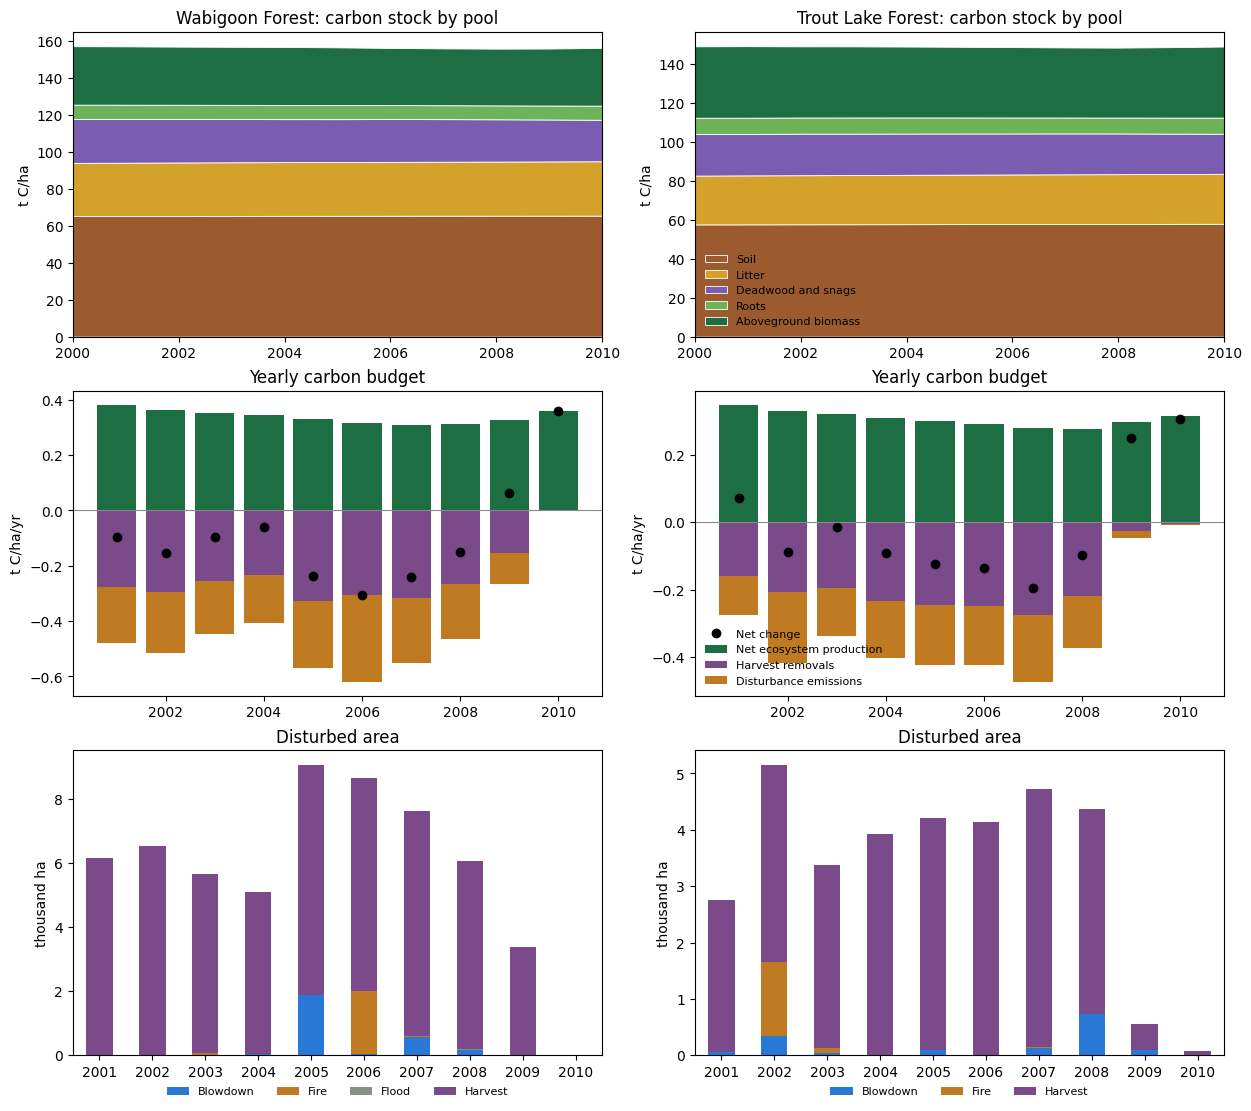

In [5]:
POOL_STYLE = [('soil', 'Soil', '#9c5b2e'), ('litter', 'Litter', '#d4a22a'), ('deadwood', 'Deadwood and snags', '#7a5cb0'),
              ('bgb', 'Roots', '#6db35a'), ('agb', 'Aboveground biomass', '#1d6f43')]
keys = list(TABLES)
fig, axes = plt.subplots(3, len(keys), figsize=(6.2 * len(keys), 11), squeeze=False, constrained_layout=True)
for j, key in enumerate(keys):
    st, bu, di = (TABLES[key][k] for k in ('carbon_stocks', 'carbon_budget', 'disturbed_area'))
    ax = axes[0, j]
    ax.stackplot(st.year, *[st[f'{k}_per_ha'] for k, _, _ in POOL_STYLE], labels=[lab for _, lab, _ in POOL_STYLE],
                 colors=[c for _, _, c in POOL_STYLE], edgecolor='white', linewidth=0.6)
    ax.set(title=f'{FORESTS[key]}: carbon stock by pool', ylabel='t C/ha', xlim=(START_YEAR, END_YEAR))
    ax = axes[1, j]
    ax.bar(bu.year, bu.nep_per_ha, color='#1d6f43', label='Net ecosystem production')
    ax.bar(bu.year, -bu.harvest_removals_per_ha, color='#7b4a8a', label='Harvest removals')
    ax.bar(bu.year, -bu.disturbance_emissions_per_ha, bottom=-bu.harvest_removals_per_ha, color='#c07a22', label='Disturbance emissions')
    ax.plot(bu.year, bu.net_change_per_ha, 'o', color='black', label='Net change')
    ax.axhline(0, color='#888', lw=0.8)
    ax.set(title='Yearly carbon budget', ylabel='t C/ha/yr')
    ax = axes[2, j]
    cols = [c for c in di.columns if c not in ('t', 'year')]
    (di.set_index('year')[cols].rename(columns=str.title) / 1000).plot.bar(
        ax=ax, stacked=True, rot=0, color=[{'HARVEST': '#7b4a8a', 'FIRE': '#c07a22', 'BLOWDOWN': '#2a78d6'}.get(c, '#8b9085') for c in cols])
    ax.set(title='Disturbed area', xlabel='', ylabel='thousand ha')
    ax.legend(ncol=4, fontsize=8, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.07))
for ax in axes[:2, -1]:
    ax.legend(loc='lower left', fontsize=8, frameon=False)
(OUT / 'figures').mkdir(parents=True, exist_ok=True)
fig.savefig(OUT / 'figures' / 'carbon_2000_2010.png', dpi=160)
plt.show()

## Join stand biomass back to the map

`stand_biomass.csv` is keyed by `PolyId` = `"Polygon"` + the inventory `POLYID` with hyphens removed. Join it to the FRI 2D polygon layer in a GIS, or in Python:

```python
import geopandas as gpd
fri = gpd.read_file("data/fri/<inventory>.gdb", layer="<forest>_2D")
fri["PolyId"] = "Polygon" + fri.POLYID.astype(str).str.replace("-", "")
fri.merge(pd.read_csv("outputs/wabigoon/stand_biomass.csv"), on="PolyId").to_file("outputs/wabigoon/stand_biomass.gpkg")
```